# 2-stage voltage PSD measurement

## Connect to Box

In [9]:
#Code originally from Igor, adapted by Matt 5/24/24
import pyvisa as visa
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
# Open hp 89441A using pyvisa package
rm = visa.ResourceManager()
ls = rm.list_resources()

#Find your instrument from this list
print(ls)

hp=rm.open_resource("GPIB2::19::INSTR")


rbw_span = 40e6/300e3
print(rbw_span)
hp.query('*IDN?') 


('USB0::0xF4EC::0x1301::SSA3XNEC6R0076::INSTR', 'TCPIP0::192.168.1.58::inst0::INSTR', 'TCPIP0::192.168.1.5::AQ6373B::INSTR', 'ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL3::INSTR', 'ASRL5::INSTR', 'ASRL6::INSTR', 'ASRL8::INSTR', 'ASRL12::INSTR', 'ASRL13::INSTR', 'ASRL14::INSTR', 'GPIB0::16::INSTR', 'GPIB1::2::INSTR', 'GPIB2::19::INSTR')
133.33333333333334


'HEWLETT-PACKARD,89410A/89431A,3416A01653/3509A00668,A.05.10/A.00.04\n'

## Define Functions

In [10]:


def remove_padding(trace_data):
    """
    This function removes padding at the beginning and end of trace data.
    According to the manual, the padding is used for alias protection.
    """
    pts=hp.query('SENSe:SWEep1:POINts?')[1:-1]  # get number of points in 'TRACE1'
    pts=int(pts)
    pad=(len(trace_data)-pts)//2
    trace_data=trace_data[pad+1:-pad]
    return trace_data


def get_trace(trace_number=1):
    """returns the x and y values of whatever is on the instrument screen"""
    
    hp.write('TRACe:COPY D{}, TRACE{}'.format(trace_number,trace_number))
    xtrace=hp.query_ascii_values('TRAC:X? D{}'.format(trace_number), container=np.array)
    ytrace=hp.query_ascii_values('CALC:DATA?')
    xtrace=remove_padding(xtrace)
#     ytrace=remove_padding(ytrace)
#     ytrace=10.*np.log10(ytrace)
    return xtrace, ytrace


def combine_data(start_freq,end_freq,average_count,trace_number=1):
    """returns x and y values for a given set of frequency range + averaging number"""
    
    hp.write('frequency:start {}'.format(start_freq))
    hp.write('frequency:stop {}'.format(end_freq))
    hp.write('average on')
    hp.write('average:count {}'.format(average_count))
    hp.write('abort')
    hp.write('*wai')
    x,y=get_trace(trace_number)
    return x,y


def get_freq_response(trace_number=1):
    """measures frequency response and returns magnitude and phase"""
    
    hp.write('TRACe:COPY D{}, TRACE{}'.format(trace_number,trace_number))
    freq = hp.query_ascii_values('TRAC:X? D{}'.format(trace_number), container=np.array)
    ytrace = hp.query_ascii_values('TRAC? D{}'.format(trace_number),container=np.array)
    magnitude = ytrace[0::2]
    phase = ytrace[1::2]
    freq = remove_padding(freq)
    magnitude = remove_padding(magnitude)
    phase = remove_padding(phase)
    magnitude = 20.*np.log10(magnitude) # units in dB
    phase = phase*180/np.pi # units in degrees
    return freq, magnitude, phase


def combine_freq_response(start_freq,end_freq,average_count,trace_number=1):
    """returns x and y values for a given set of frequency range + averaging number"""
    
    hp.write('frequency:start {}'.format(start_freq))
    hp.write('frequency:stop {}'.format(end_freq))
    hp.write('average on')
    hp.write('average:count {}'.format(average_count))
    hp.write('abort')
    hp.write('*wai')
    freq, magnitude, phase = get_freq_response(trace_number)
    return freq, magnitude, phase


def prep_for_measurement():
    #Set AC Coupling and 50 Ohm termination, scalar mode operation, PSD mode
    hp.write("input1:coupling ac")
    hp.write("input1:impedance 50")
    hp.write("instrument:select scalar")
    hp.write("calculate1:feed XFR:POW:PSD 1")
    hp.write("calculate1:unit:POW Vrms/rtHz")
    # hp.write("calculate1:unit:POW W/Hz")

    hp.write("memory:mallocate:measurement:fpoints 1601")
    # hp.write("sense:sweep1:points 257")
    hp.write("sense:sweep1:points 1601")

    hp.write("sense:sweep1:points?")
    hp.write("sense:bandwidth:mode:arbitrary on")     #This enables one to set the rbw to any value, not just 1,3,10 values.
    hp.write("sense:bandwidth:resolution:auto on")
    
    # hp.write("INP1:FILT:LPAS:STAT OFF")  # Turn off anti-aliasing lowpass filter. Necessary at low frequencies
    
    print("Channel 1 input coupling: " + hp.query("input1:coupling?"))
    print("Channel 1 termination: " + hp.query("input1:impedance?"))
    print("Instrument mode: " + hp.query("instrument?"))
    print("Instrument displaying: " + hp.query("calculate1:feed?"))
    print("Units of measurement: " + hp.query("calculate1:unit:power?"))
    print("Number of points per frequency bin: "+ hp.query("sense:sweep1:points?"))
    print("RBW change with current span (auto)? " + hp.query("sense:bandwidth:resolution:auto?"))
    print(f'Anti-aliasing lowpass filter: {hp.query("INP1:FILT:LPAS:STAT?")}')
    

hp.timeout=None     # disable timeout
hp.query('*IDN?')   # check if instrument is responding

prep_for_measurement()

Channel 1 input coupling: +1601AC

Channel 1 termination: +5.00000000000000E+001

Instrument mode: SCAL

Instrument displaying: "XFR:POW:PSD 1"

Units of measurement: VRMS/RTHZ

Number of points per frequency bin: +1601

RBW change with current span (auto)? ON

Anti-aliasing lowpass filter: +1



## Collect Data

In [ ]:
#This cell can be used with the HP89441A. This has larger measurement bandwidth from DC to 2.6GHz.

start_freq = 1000
stop_freq = 50e6
num_bins = 6
averages= 100


def make_freq_array(freq_list): #Creates array of successive frequency ranges in the frequency list. --> [a,b,c] --> [[a,b],[b,c]]
    freq_start_stop = [[freq_list[i], freq_list[i+1]] for i in range (len(freq_list)-1)]
    return freq_start_stop

def get_multiple_traces(freq_array, average): #Takes array of successive frequency ranges and returns the stitched lists of x and y values
    xtraces = []
    ytraces = []
    for el in freq_array:
        x,y=combine_data(el[0],el[1],average)
        xtraces.extend(x)
        ytraces.extend(y)
    return xtraces, ytraces   
    
    
prep_for_measurement() 
    
if stop_freq <= 10e6:
    #In this case you only need to use the low frequency input channel
    print("Under 10MHz")
    hp.write("ROUTe:RECeiver RF1")
    freq_list = np.logspace(np.log10(start_freq), np.log10(stop_freq), num=num_bins, base=10) #Make even measurement intervals on a log10 scale
    freq_array = make_freq_array(freq_list)
    x, y = get_multiple_traces(freq_array, averages)
else:
    #In this case you need to use both the high and low frequency channels.
    x=[]
    y=[]
    
    freq_list_low = np.logspace(np.log10(start_freq), np.log10(10e6), num=num_bins-1)
    freq_list_high = np.logspace(np.log10(10e6), np.log10(stop_freq), num=2) #Figure out the number of bin issue later
    
    freq_array_low = make_freq_array(freq_list_low)
    freq_array_high = make_freq_array(freq_list_high)
    
    hp.write("ROUTe:RECeiver RF1")
    x1, y1 = get_multiple_traces(freq_array_low,averages)
    
    
    hp.write("ROUTe:RECeiver RF2")
    # hp.write(":SENS:VOLT:RANG -50DBM")
    x2, y2 = get_multiple_traces(freq_array_high,averages)
    
    x.extend(x1)
    x.extend(x2)
    
    y.extend(y1)
    y.extend(y2)
    

plt.loglog(x,y) #v/rtHz
plt.show()

trace=np.vstack((x,y)).T # combine x and y data as a 2d array
logdir =  Path(r"Z:\Research Projects\UVDCS\Data\6-29-2026\z:\Research Projects\UVDCS\Data\6-29-2026\Mikey Osc RIN Extended")
# logfile= logdir / "InstrumentNoiseFloor.txt"
# logfile= logdir / r"DetectorNoiseFloor.txt"
logfile= logdir / "LightNoise.txt"
# logfile= logdir / r"spectrum14.txt"
# logfile= logdir / r"detector_background.txt"
# logfile= logdir / r"instrument_background.txt"
np.savetxt(logfile,trace)

Channel 1 input coupling: +1601AC

Channel 1 termination: +5.00000000000000E+001

Instrument mode: SCAL

Instrument displaying: "XFR:POW:PSD 1"

Units of measurement: VRMS/RTHZ

Number of points per frequency bin: +1601

RBW change with current span (auto)? ON

Anti-aliasing lowpass filter: +1



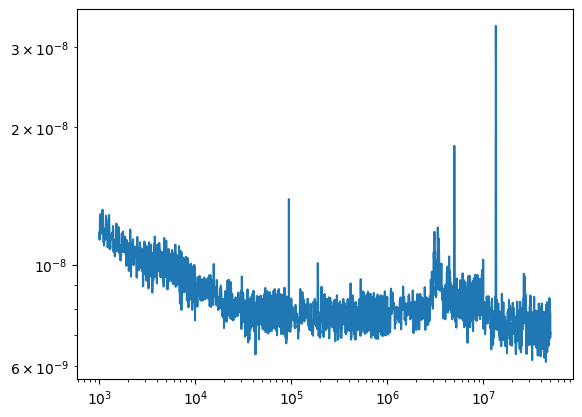

In [ ]:
def plot(file_loc):
    dat = np.genfromtxt(file_loc)
    plt.loglog(dat[:,0],dat[:,1])

f1=logdir / r"\InstrumentNoiseFloor.txt"
# f1=logdir + r"\InstrumentNoiseFloor.txt"
# f1 = r"C:\Users\Diddams\OneDrive - UCB-O36\Diddams Lab\Research Projects\EOS V2\CLEO 2025 Submission\11.20.24 Electrical Spectrum\Electrical Spectrum with Signal.txt"
# f2 = r"C:\Users\Diddams\OneDrive - UCB-O365\Diddams Lab\Research Projects\EOS V2\CLEO 2025 Submission\11.20.24 Electrical Spectrum\Electrical Spectrum - Readout Pulse Only.txt"
# f3 = r"C:\Users\Diddams\OneDrive - UCB-O365\Diddams Lab\Research Projects\EOS V2\CLEO 2025 Submission\11.20.24 Electrical Spectrum\PDB Noise Floor.txt"
# f4 = r"C:\Users\Diddams\OneDrive - UCB-O365\Diddams Lab\Research Projects\EOS V2\CLEO 2025 Submission\11.20.24 Electrical Spectrum\HP Box Noise Floor.txt"
plot(f1)
# plot(f2)
# plot(f3)
# plot(f4)